In [11]:
from qiskit import QuantumCircuit   
from qiskit_aer import Aer 

bd=Aer.get_backend("statevector_simulator")

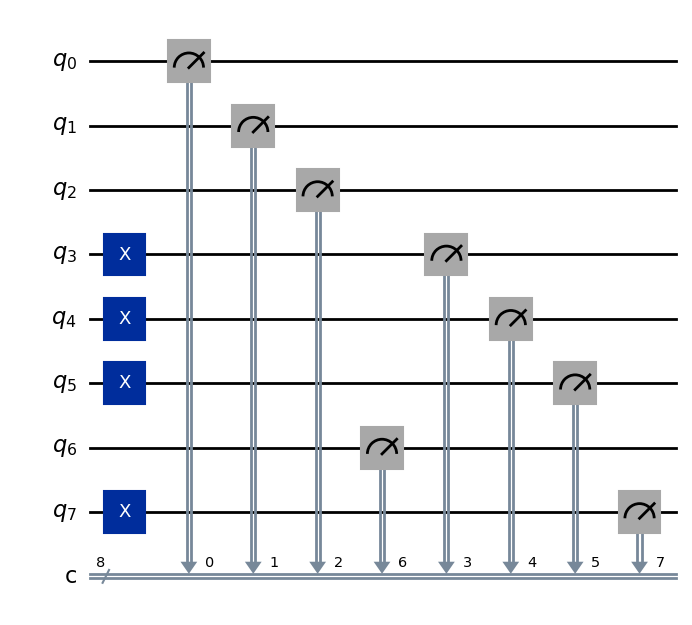

In [12]:
# Binary data from IoT (DHT11 temperature = 29°C)
binary_data = "00011101"

n = len(binary_data)
qc = QuantumCircuit(n, n)

# Encode bits into qubits
for i, bit in enumerate(binary_data):
    if bit == "1":
        qc.x(i)

# Measure all qubits
qc.measure(range(n), range(n))
qc.draw("mpl")


In [13]:
job=bd.run(qc,shot=1023)
result=job.result()
print(result)

Result(backend_name='statevector_simulator', backend_version='0.17.2', job_id='21ca315e-2057-447f-afd8-30e7037c1c8a', success=True, results=[ExperimentResult(shots=1, success=True, meas_level=2, data=ExperimentResultData(counts={'0xb8': 1}, statevector=Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0

In [15]:
counts=result.get_counts()  # getting number of times that string was observed 

measured_binary = list(counts.keys())[0]
decoded_temp = int(measured_binary[::-1], 2)

print("Measured Binary:", measured_binary)
print("Decoded Temperature:", decoded_temp, "°C")

Measured Binary: 10111000
Decoded Temperature: 29 °C
